ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

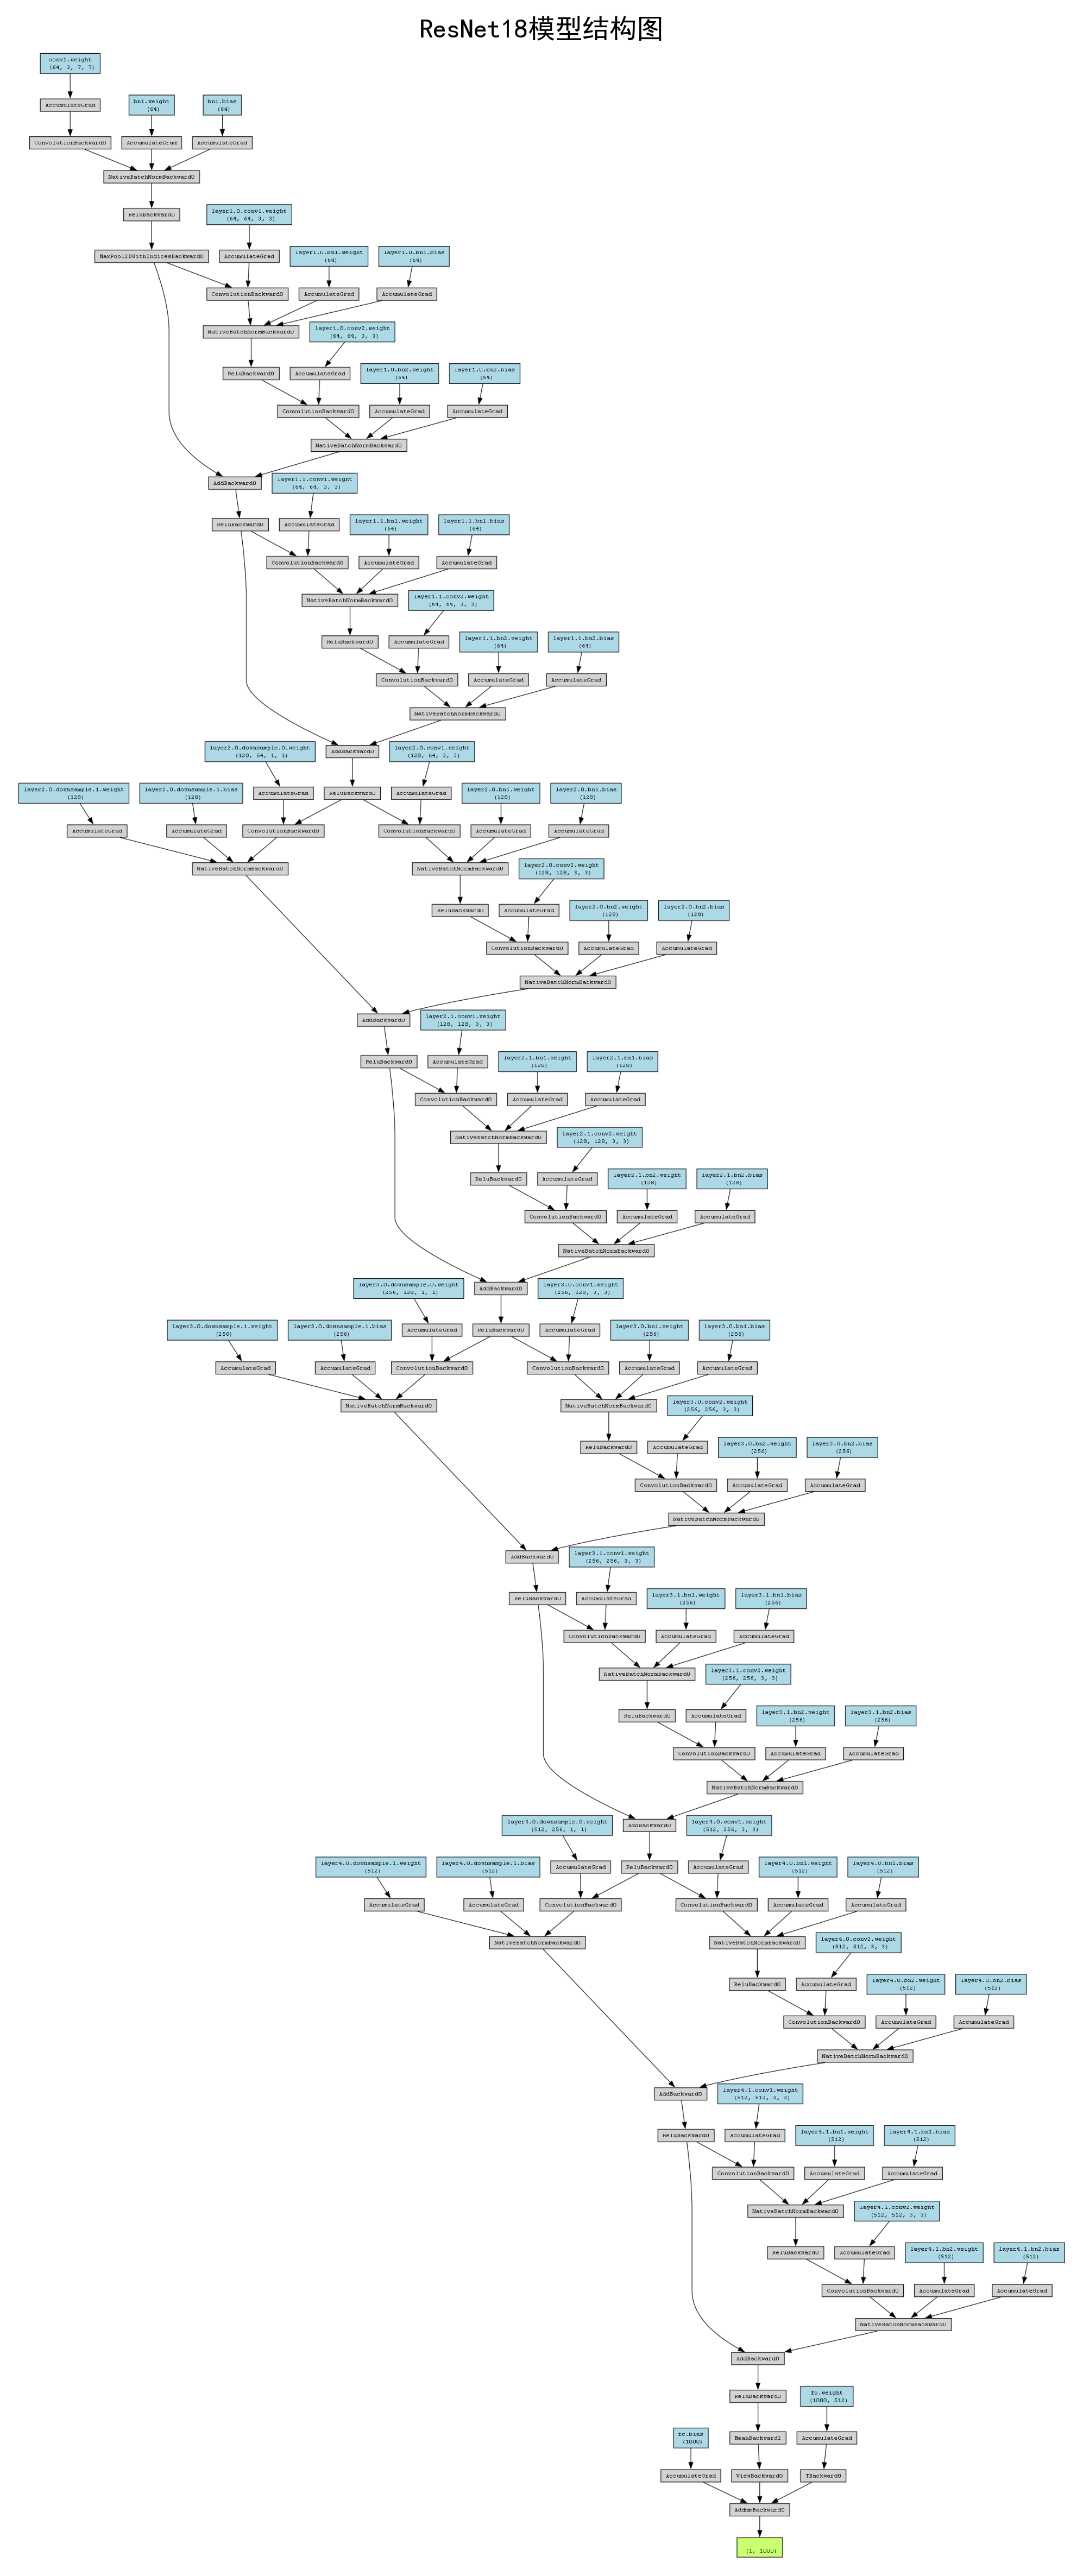

ResNet18模型的详细参数信息:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14

In [1]:
import torchvision.models as models

import torchvision.models as models

# 加载预训练的ResNet18模型
# 不加载预训练权重，仅初始化模型结构
resnet18 = models.resnet18(weights=None)

# 打印模型结构
print(resnet18)
total_params = sum(p.numel() for p in resnet18.parameters())
print(f"resnet18模型的总参数量: {total_params:,}")

# 导入可视化模型结构所需的库
import torch
from torchviz import make_dot
from torch.autograd import Variable
import matplotlib.pyplot as plt
import io
from PIL import Image
from torchsummary import summary
import numpy as np

# 创建一个示例输入
x = torch.randn(1, 3, 224, 224)

# 获取模型输出
y = resnet18(x)
# 设置matplotlib支持中文字体
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 增加一些常见的中文字体
rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 使用make_dot生成计算图
dot = make_dot(y, params=dict(resnet18.named_parameters()))

# 保存计算图为图片
dot.format = 'png'
dot.render("resnet18_structure", cleanup=True)

# 显示模型结构图
try:
    img = Image.open("resnet18_structure.png")
    plt.figure(figsize=(15, 20),dpi=300)
    plt.imshow(np.array(img))
    plt.axis('off')
    plt.title("ResNet18模型结构图")
    plt.show()
except:
    print("无法显示图像，请检查torchviz是否正确安装")

# 使用torchsummary打印模型的详细参数信息
print("ResNet18模型的详细参数信息:")
summary(resnet18, (3, 224, 224), device="cpu")


In [4]:
import torch
from torch import nn

# 创建输入张量，假设batch_size=1, channels=3, 高=32, 宽=32
x = torch.randn(1, 3, 32, 32)

# 定义一个单独的卷积层，kernel_size=3, stride=2, padding='same'
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=0)

# 前向传播运算
y = conv(x)

print(f"输入形状: {x.shape}")
print(f"输出形状: {y.shape}")


输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 3, 15, 15])
